**PERSONALITY PREDICTION SYSTEM**

---



**Install Required Libraries**

In [2]:
# ================================================================
# CELL 1 — Install Required Libraries
# ================================================================

!pip install pdfplumber python-docx spacy scikit-learn pandas numpy matplotlib seaborn -q
!python -m spacy download en_core_web_sm -q

print("✅ All Libraries Installed Successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All Libraries Installed Successfully!


**Import Libraries**

In [3]:
# ================================================================
# CELL 2 — Import Required Libraries
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
import pdfplumber
import spacy
from docx import Document
from google.colab import files
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Load spaCy NLP model
nlp = spacy.load('en_core_web_sm')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


**Load Training Dataset & Train Models**

In [4]:
# ================================================================
# CELL 3 — Load Training Dataset and Train ML Models
# ================================================================

df = pd.read_csv('/content/training_dataset.csv')
df.columns = df.columns.str.strip()
df.rename(columns={'Personality (Class label)': 'Personality'}, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print(f"✅ Training Dataset Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Classes: {list(df['Personality'].unique())}")

# Encode gender
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['Gender'])

# Encode target label
le_target = LabelEncoder()
df['Personality_enc'] = le_target.fit_transform(df['Personality'])

# Features & Target
feature_cols = [
    'Gender_enc','Age','openness','neuroticism',
    'conscientiousness','agreeableness','extraversion'
]

X = df[feature_cols].values
y = df['Personality_enc'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("🔄 Training 3 Machine Learning Models...")

models_def = {
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial', solver='newton-cg',
        max_iter=1000, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
trained_ml = {}

for name, model in models_def.items():

    model.fit(X_train_s, y_train)
    trained_ml[name] = model

    y_pred = model.predict(X_test_s)

    cv_scores = cross_val_score(model, X_train_s, y_train,
                                cv=cv, scoring='accuracy')

    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred)*100,2),
        'Precision': round(precision_score(y_test, y_pred,
                     average='weighted', zero_division=0)*100,2),
        'Recall': round(recall_score(y_test, y_pred,
                     average='weighted', zero_division=0)*100,2),
        'F1 Score': round(f1_score(y_test, y_pred,
                     average='weighted', zero_division=0)*100,2),
        'CV Mean': round(cv_scores.mean()*100,2),
        'CV Std': round(cv_scores.std()*100,2),
        'y_pred': y_pred
    }

    print(f"   ✅ {name}: Accuracy={results[name]['Accuracy']}%  F1={results[name]['F1 Score']}%")

# Select Best Model
best_name = max(results, key=lambda m: results[m]['F1 Score'])
best_model = trained_ml[best_name]

print(f"\n🏆 Best Model Selected: {best_name}")

✅ Training Dataset Loaded: 703 rows × 8 columns
   Classes: ['extraverted', 'serious', 'dependable', 'lively', 'responsible']
🔄 Training 3 Machine Learning Models...
   ✅ Logistic Regression: Accuracy=20.57%  F1=18.58%
   ✅ Random Forest: Accuracy=27.66%  F1=26.66%
   ✅ Gradient Boosting: Accuracy=29.79%  F1=29.55%

🏆 Best Model Selected: Gradient Boosting


**Model Evaluation Graphs**

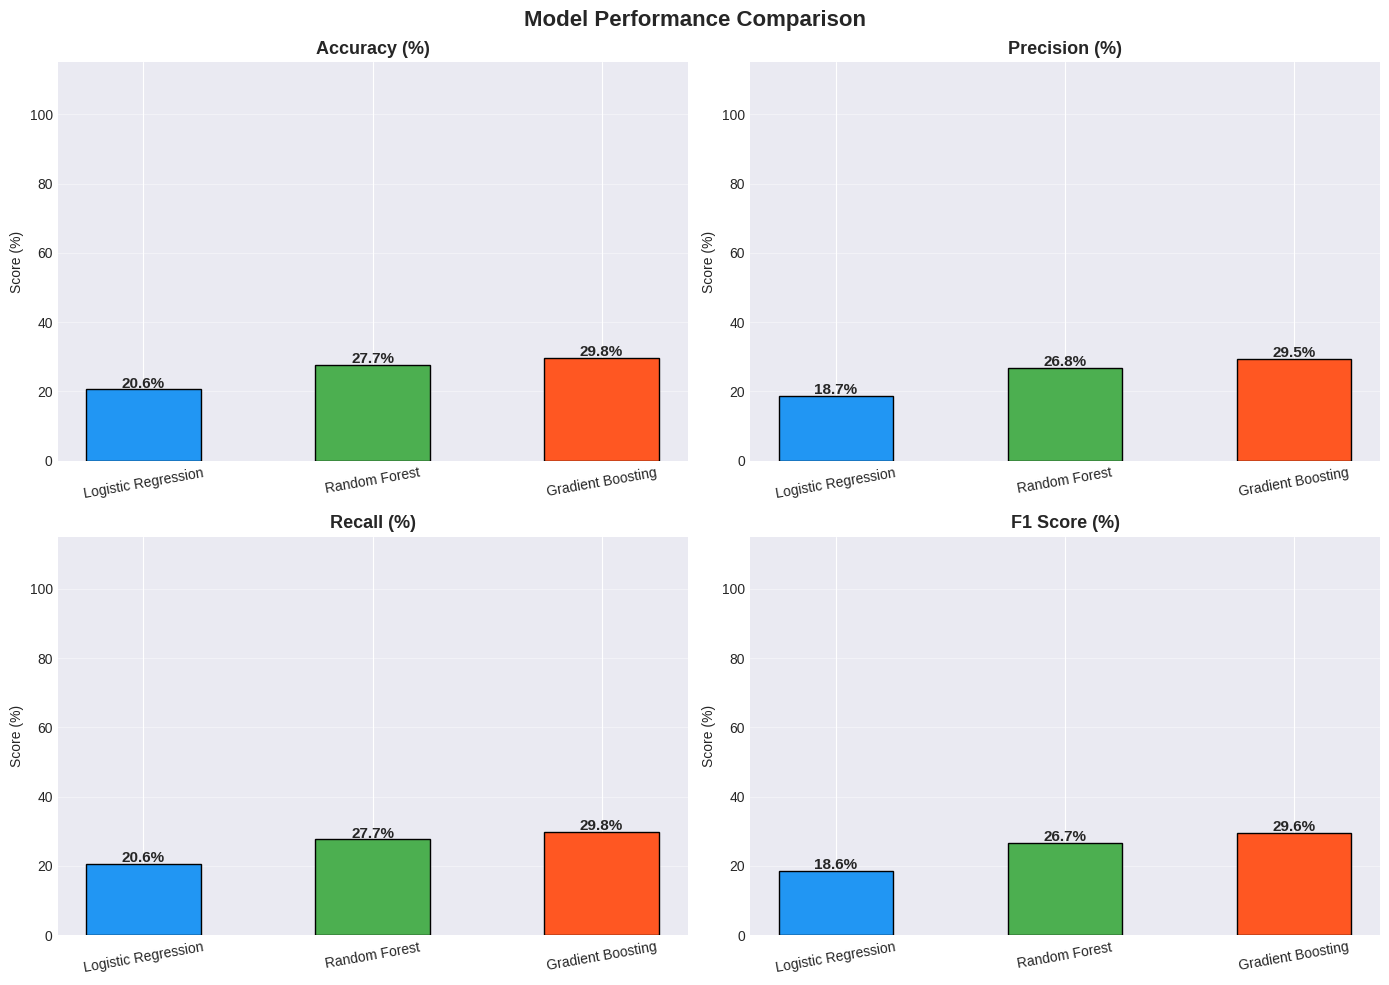

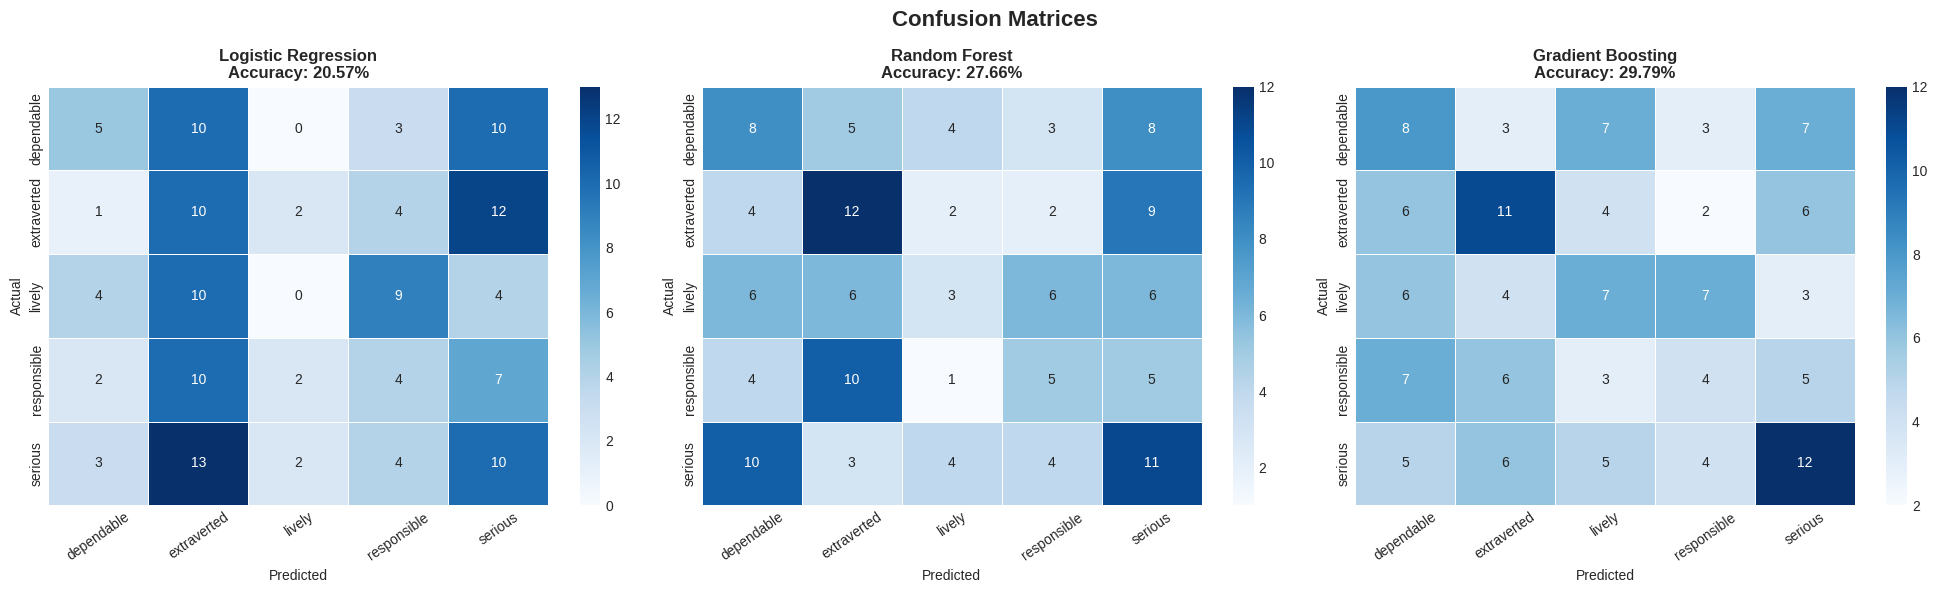


📋 Detailed Classification Reports:

── Logistic Regression ──
              precision    recall  f1-score   support

  dependable       0.33      0.18      0.23        28
 extraverted       0.19      0.34      0.24        29
      lively       0.00      0.00      0.00        27
 responsible       0.17      0.16      0.16        25
     serious       0.23      0.31      0.27        32

    accuracy                           0.21       141
   macro avg       0.18      0.20      0.18       141
weighted avg       0.19      0.21      0.19       141


── Random Forest ──
              precision    recall  f1-score   support

  dependable       0.25      0.29      0.27        28
 extraverted       0.33      0.41      0.37        29
      lively       0.21      0.11      0.15        27
 responsible       0.25      0.20      0.22        25
     serious       0.28      0.34      0.31        32

    accuracy                           0.28       141
   macro avg       0.27      0.27      0.26    

In [5]:
# ================================================================
# CELL 4 — Model Evaluation Graphs
# ================================================================

colors = sns.color_palette('husl', df['Personality'].nunique())
bar_colors = ['#2196F3', '#4CAF50', '#FF5722']

# ------------------------------------------------
# Graph 1 — Model Metrics Comparison
# ------------------------------------------------
metric_keys = ['Accuracy','Precision','Recall','F1 Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for i, key in enumerate(metric_keys):

    ax = axes[i//2][i%2]
    vals = [results[m][key] for m in results]

    bars = ax.bar(list(results.keys()), vals,
                  color=bar_colors,
                  edgecolor='black',
                  width=0.5)

    for bar, val in zip(bars, vals):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    ax.set_title(f'{key} (%)', fontsize=13, fontweight='bold')
    ax.set_ylim(0,115)
    ax.set_ylabel('Score (%)')
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# Graph 2 — Confusion Matrices
# ------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for i, (name, m) in enumerate(results.items()):

    cm = confusion_matrix(y_test, m['y_pred'])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le_target.classes_,
        yticklabels=le_target.classes_,
        ax=axes[i],
        linewidths=0.5
    )

    axes[i].set_title(f'{name}\nAccuracy: {m["Accuracy"]}%', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# Graph 3 — Classification Reports
# ------------------------------------------------

print("\n📋 Detailed Classification Reports:")

for name, m in results.items():

    print(f"\n── {name} ──")

    print(
        classification_report(
            y_test,
            m['y_pred'],
            target_names=le_target.classes_,
            zero_division=0
        )
    )

print("✅ All Evaluation Graphs Generated Successfully!")

**Resume Text Extraction (PDF + DOCX)**

In [6]:
# ================================================================
# CELL 5 — Resume Text Extraction Functions
# ================================================================

def extract_text_from_pdf(path):
    """
    Extract text from a PDF file using pdfplumber
    """
    text = ""

    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()

            if page_text:
                text += page_text + "\n"

    return text.strip()


def extract_text_from_docx(path):
    """
    Extract text from a DOCX file using python-docx
    """

    doc = Document(path)

    text = "\n".join(
        [para.text for para in doc.paragraphs if para.text.strip()]
    )

    return text.strip()


def extract_resume_text(path):
    """
    Extract text from a resume file.
    Supports both PDF and DOCX formats.
    """

    ext = os.path.splitext(path)[1].lower()

    if ext == '.pdf':
        return extract_text_from_pdf(path)

    elif ext in ['.docx', '.doc']:
        return extract_text_from_docx(path)

    else:
        raise ValueError(
            f"Only PDF or DOCX files are supported. '{ext}' is not supported."
        )


print("✅ Resume Text Extraction Functions Ready!")

✅ Resume Text Extraction Functions Ready!


**NLP: Extract OCEAN Personality Features**

In [7]:
# ================================================================
# CELL 6 — NLP: Automatic OCEAN Personality Feature Extraction
# ================================================================

# ----- Big Five (OCEAN) Trait Keywords -----
# These keywords will be searched in resume text.
# More keywords found → higher score (1–10 scale).

TRAIT_KEYWORDS = {

    'openness': [
        'creative', 'innovative', 'imaginative', 'curious', 'artistic',
        'research', 'design', 'invented', 'developed', 'explore',
        'learning', 'new technologies', 'experimental', 'novel',
        'brainstorm', 'vision', 'ideas', 'discovery',
        'poetry', 'literature', 'philosophy', 'diverse', 'unique',
        'open-minded', 'flexible thinking', 'conceptual', 'abstract',
        'intellectual', 'analytical thinking', 'problem solving',
        'data science', 'machine learning', 'ai', 'deep learning'
    ],

    'conscientiousness': [
        'organized', 'responsible', 'punctual', 'detail-oriented',
        'systematic', 'thorough', 'disciplined', 'reliable', 'diligent',
        'planned', 'structured', 'managed', 'led', 'delivered',
        'deadline', 'goal', 'target', 'achieved', 'completed',
        'certified', 'award', 'excellence', 'quality', 'accuracy',
        'professional', 'dedicated', 'committed', 'follow-through',
        'methodical', 'precise', 'careful', 'consistent', 'efficient',
        'project management', 'time management', 'organized team'
    ],

    'extraversion': [
        'leadership', 'team leader', 'public speaking', 'presentation',
        'networking', 'collaborated', 'social', 'outgoing', 'motivated',
        'energetic', 'enthusiastic', 'confident', 'assertive',
        'sales', 'marketing', 'client', 'customer', 'communication',
        'event', 'workshop', 'seminar', 'conference', 'training',
        'mentored', 'coached', 'team building', 'coordinated',
        'community', 'volunteered', 'ambassador', 'spokesperson'
    ],

    'agreeableness': [
        'teamwork', 'cooperative', 'helpful', 'supportive', 'empathetic',
        'compassionate', 'caring', 'patient', 'understanding', 'kind',
        'collaborative', 'friendly', 'warm', 'trusting', 'honest',
        'volunteer', 'charity', 'community service', 'helping',
        'mentor', 'counseled', 'assisted', 'resolved conflict',
        'mediated', 'facilitated', 'accommodating', 'flexible',
        'harmonious', 'diplomatic', 'considerate', 'generous'
    ],

    'neuroticism': [
        # High = more stress/negative traits
        'stress', 'anxiety', 'overwhelmed', 'pressure', 'challenges',
        'struggled', 'difficult', 'conflict', 'issue', 'problem',
        'failed', 'mistake', 'concern', 'worry', 'frustrated',
        'uncertain', 'unstable', 'sensitive', 'emotional',
        # Positive keywords → reduce neuroticism
        'calm', 'composed', 'resilient', 'stable', 'balanced',
        'stress management', 'adaptable', 'consistent performance',
        'under pressure', 'crisis management', 'cool-headed'
    ]
}

# Neuroticism negative keywords reduce score
NEUROTICISM_NEGATIVE = [
    'calm', 'composed', 'resilient', 'stable', 'balanced',
    'stress management', 'adaptable', 'consistent performance',
    'cool-headed', 'crisis management', 'under pressure'
]

# ---------------------------------------------------------
# Function to score each trait
# ---------------------------------------------------------

def score_trait(text, keywords, trait_name, base=3, scale=7):
    """
    Calculate trait score based on keywords found in resume text.

    Logic:
    - ratio = #keywords found / total keywords
    - Score = base + ratio * scale
    - Clamp score between 1 and 10
    - For neuroticism, negative keywords reduce the score
    """

    text_lower = text.lower()
    found = sum(1 for kw in keywords if kw in text_lower)
    total = len(keywords)
    ratio = found / total

    if trait_name == 'neuroticism':
        neg_found = sum(1 for kw in NEUROTICISM_NEGATIVE if kw in text_lower)
        neg_ratio = neg_found / len(NEUROTICISM_NEGATIVE)
        ratio = max(0, ratio - neg_ratio * 0.5)

    raw_score = base + ratio * scale
    score = max(1, min(10, round(raw_score)))

    return score, found


# ---------------------------------------------------------
# Function to extract personal info (name, age, gender)
# ---------------------------------------------------------

def extract_personal_info(text):
    """Detect name, age, and gender from resume text"""

    doc_nlp = nlp(text)

    # Name detection using NER
    name = "Unknown"
    for ent in doc_nlp.ents:
        if ent.label_ == 'PERSON':
            name = ent.text
            break

    # Age detection using regex
    age = 22
    age_patterns = [
        r'age[:\s]+(\d{2})',
        r'(\d{2})\s*years?\s*old',
        r'dob[:\s]+\d{1,2}[/-]\d{1,2}[/-](\d{4})',
        r'born[:\s]+\d{1,2}[/-]\d{1,2}[/-](\d{4})'
    ]
    for pattern in age_patterns:
        match = re.search(pattern, text.lower())
        if match:
            val = int(match.group(1))
            if val > 1900:
                age = 2025 - val
            elif 15 <= val <= 70:
                age = val
            break

    # Gender detection
    gender = 'Male'
    text_lower = text.lower()
    female_words = ['she', 'her', 'ms.', 'mrs.', 'miss', 'female', 'woman', 'girl']
    male_words   = ['he', 'his', 'mr.', 'male', 'man', 'boy']

    female_count = sum(1 for w in female_words if w in text_lower)
    male_count   = sum(1 for w in male_words if w in text_lower)

    if female_count > male_count:
        gender = 'Female'

    return name, age, gender

**Resume Analysis & Section Extraction**

In [8]:
# ---------------------------------------------------------
# Function to extract resume sections
# ---------------------------------------------------------

def extract_resume_sections(text):
    """Detect important resume sections: Skills, Experience, Education, Projects"""

    sections = {
        'Skills':     '',
        'Experience': '',
        'Education':  '',
        'Projects':   ''
    }

    text_lower = text.lower()

    # Skills
    skill_match = re.search(
        r'(skills?|technical skills?|core competencies)[:\s]*([^\n]{20,200})',
        text_lower
    )
    if skill_match:
        sections['Skills'] = skill_match.group(2).strip()[:150]

    # Experience
    exp_match = re.search(
        r'(experience|work experience|employment)[:\s]*([^\n]{20,200})',
        text_lower
    )
    if exp_match:
        sections['Experience'] = exp_match.group(2).strip()[:150]

    # Education
    edu_match = re.search(
        r'(education|academic|qualification)[:\s]*([^\n]{20,200})',
        text_lower
    )
    if edu_match:
        sections['Education'] = edu_match.group(2).strip()[:150]

    # Projects
    proj_match = re.search(
        r'(projects?|portfolio)[:\s]*([^\n]{20,200})',
        text_lower
    )
    if proj_match:
        sections['Projects'] = proj_match.group(2).strip()[:150]

    return sections


# ---------------------------------------------------------
# Main Resume Analysis Function
# ---------------------------------------------------------

def analyze_resume(file_path):
    """
    Complete resume analysis:
    1. Extract text
    2. Detect personal info
    3. Calculate OCEAN trait scores
    4. Predict personality using ML model
    """

    print("\n" + "="*55)
    print("  📄 STARTING RESUME ANALYSIS")
    print("="*55)

    # Step 1 — Extract text
    print("\n🔄 Step 1: Extracting text from resume ...")
    text = extract_resume_text(file_path)

    if not text or len(text) < 50:
        print("⚠️ Resume text too short. Enter values manually.")
        return None

    print(f"   ✅ {len(text)} characters extracted")
    print("\n📝 Resume Text Preview (first 500 characters):")
    print("-"*50)
    print(text[:500])
    print("-"*50)

    # Step 2 — Personal info
    print("\n🔄 Step 2: Detecting personal information ...")
    name, age, gender = extract_personal_info(text)
    print(f"   👤 Name   : {name}")
    print(f"   📅 Age    : {age}")
    print(f"   ⚧ Gender : {gender}")

    # Step 3 — OCEAN scores
    print("\n🔄 Step 3: Calculating Big Five (OCEAN) traits ...")
    trait_scores = {}
    trait_found  = {}

    for trait, keywords in TRAIT_KEYWORDS.items():
        score, found = score_trait(text, keywords, trait)
        trait_scores[trait] = score
        trait_found[trait]  = found
        print(f"   📊 {trait.title():<20} Score: {score:>2}/10 "
              f"(Keywords found: {found}/{len(keywords)})")

    # Step 4 — Extract resume sections
    print("\n🔄 Step 4: Extracting resume sections ...")
    sections = extract_resume_sections(text)
    for sec, content in sections.items():
        if content:
            print(f"   ✅ {sec}: {content[:80]}...")

    # Step 5 — Predict personality
    print("\n🔄 Step 5: Predicting personality using ML model ...")
    gender_enc = 1 if gender.lower() == 'male' else 0

    inp = np.array([[
        gender_enc,
        age,
        trait_scores['openness'],
        trait_scores['neuroticism'],
        trait_scores['conscientiousness'],
        trait_scores['agreeableness'],
        trait_scores['extraversion']
    ]])

    inp_scaled = scaler.transform(inp)
    pred_enc   = best_model.predict(inp_scaled)[0]
    pred_label = le_target.inverse_transform([pred_enc])[0]
    pred_proba = best_model.predict_proba(inp_scaled)[0]
    confidence = pred_proba.max() * 100
    proba_dict = dict(zip(le_target.classes_, (pred_proba*100).round(2)))

    return {
        'name':          name,
        'age':           age,
        'gender':        gender,
        'text':          text,
        'trait_scores':  trait_scores,
        'trait_found':   trait_found,
        'sections':      sections,
        'prediction':    pred_label,
        'confidence':    confidence,
        'probabilities': proba_dict
    }


print("✅ Resume Analysis Functions Ready!")

✅ Resume Analysis Functions Ready!


**Visualize Resume Analysis Results**

In [9]:
# ================================================================
# CELL 7 — Visualization of Resume Analysis Results
# ================================================================

def plot_resume_results(result):
    """
    Visualize resume analysis results:
    - OCEAN Radar Chart
    - Trait Scores Bar Chart
    - Prediction Probabilities
    - Keywords Found per Trait
    - Model Performance Comparison
    - Candidate Info Card
    """

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(
        f"Resume Analysis: {result['name']} — Predicted: {result['prediction'].upper()}",
        fontsize=16, fontweight='bold', y=1.01
    )

    # ----- Graph 1: OCEAN Radar Chart -----
    ax1 = fig.add_subplot(2, 3, 1, polar=True)
    traits = list(result['trait_scores'].keys())
    scores = list(result['trait_scores'].values())
    N = len(traits)
    angles = [n/float(N)*2*np.pi for n in range(N)]
    angles += angles[:1]
    scores_plot = scores + scores[:1]

    ax1.set_theta_offset(np.pi/2)
    ax1.set_theta_direction(-1)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels([t.title() for t in traits], size=9)
    ax1.set_ylim(0, 10)
    ax1.plot(angles, scores_plot, 'o-', linewidth=2, color='#2196F3')
    ax1.fill(angles, scores_plot, alpha=0.25, color='#2196F3')
    ax1.set_title('OCEAN Radar Chart', fontsize=11, fontweight='bold', pad=15)

    # ----- Graph 2: Trait Scores Bar Chart -----
    ax2 = fig.add_subplot(2, 3, 2)
    trait_colors = sns.color_palette('husl', N)
    bars = ax2.bar([t.title() for t in traits], scores, color=trait_colors, edgecolor='black')
    for bar, val in zip(bars, scores):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val),
                 ha='center', fontsize=11, fontweight='bold')
    ax2.set_ylim(0,12)
    ax2.set_title('OCEAN Feature Scores (1-10)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Score')
    ax2.tick_params(axis='x', rotation=25)
    ax2.grid(axis='y', alpha=0.4)
    ax2.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Midpoint (5)')
    ax2.legend(fontsize=8)

    # ----- Graph 3: Prediction Probabilities -----
    ax3 = fig.add_subplot(2, 3, 3)
    proba_sorted = sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True)
    p_labels = [p[0] for p in proba_sorted]
    p_values = [p[1] for p in proba_sorted]
    p_colors = ['#FF5722' if p==result['prediction'] else '#90CAF9' for p in p_labels]
    hbars = ax3.barh(p_labels, p_values, color=p_colors, edgecolor='black')
    for bar, val in zip(hbars, p_values):
        ax3.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax3.set_xlim(0,115)
    ax3.set_xlabel('Probability (%)')
    ax3.set_title('Prediction Probabilities', fontsize=11, fontweight='bold')
    ax3.grid(axis='x', alpha=0.4)

    # ----- Graph 4: Keywords Found per Trait -----
    ax4 = fig.add_subplot(2, 3, 4)
    found_vals = [result['trait_found'][t] for t in traits]
    total_vals = [len(TRAIT_KEYWORDS[t]) for t in traits]
    x = np.arange(len(traits))
    width = 0.35
    ax4.bar(x - width/2, total_vals, width, label='Total Keywords', color='#E0E0E0', edgecolor='black')
    ax4.bar(x + width/2, found_vals, width, label='Keywords Found', color='#4CAF50', edgecolor='black')
    ax4.set_xticks(x)
    ax4.set_xticklabels([t.title() for t in traits], rotation=25)
    ax4.set_title('Keywords Found in Resume', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Count')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.4)

    # ----- Graph 5: Model Performance Comparison -----
    ax5 = fig.add_subplot(2, 3, 5)
    model_names = list(results.keys())
    accs = [results[m]['Accuracy'] for m in model_names]
    f1s  = [results[m]['F1 Score'] for m in model_names]
    x2 = np.arange(len(model_names))
    ax5.bar(x2-0.2, accs, 0.35, label='Accuracy', color='#2196F3', edgecolor='black')
    ax5.bar(x2+0.2, f1s, 0.35, label='F1 Score', color='#FF9800', edgecolor='black')
    ax5.set_xticks(x2)
    ax5.set_xticklabels(model_names, rotation=10, fontsize=9)
    ax5.set_ylim(0,115)
    ax5.set_title('Model Performance', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Score (%)')
    ax5.legend()
    ax5.grid(axis='y', alpha=0.4)

    # ----- Graph 6: Candidate Info Card -----
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    info_text = (
        f"CANDIDATE PROFILE\n\n"
        f"Name      : {result['name']}\n"
        f"Gender    : {result['gender']}\n"
        f"Age       : {result['age']}\n\n"
        f"OCEAN SCORES\n\n"
        f"Openness          : {result['trait_scores']['openness']}/10\n"
        f"Conscientiousness : {result['trait_scores']['conscientiousness']}/10\n"
        f"Extraversion      : {result['trait_scores']['extraversion']}/10\n"
        f"Agreeableness     : {result['trait_scores']['agreeableness']}/10\n"
        f"Neuroticism       : {result['trait_scores']['neuroticism']}/10\n\n"
        f"PREDICTION\n\n"
        f"Personality  : {result['prediction'].upper()}\n"
        f"Confidence   : {result['confidence']:.1f}%\n"
        f"Best Model   : {best_name}"
    )
    ax6.text(0.05, 0.95, info_text, transform=ax6.transAxes,
             fontsize=9.5, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

    plt.tight_layout()
    plt.savefig('resume_analysis_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Result Graph Saved: resume_analysis_result.png")


print("✅ Visualization Functions Ready!")

✅ Visualization Functions Ready!


**Resume Upload & Analyze**

   📤 UPLOAD YOUR RESUME (PDF or DOCX)

⬇️ File chooser will open — select your resume



Saving cv.pdf to cv.pdf

✅ File Uploaded: cv.pdf
   File Size: 92,842 bytes

  📄 STARTING RESUME ANALYSIS

🔄 Step 1: Extracting text from resume ...
   ✅ 1356 characters extracted

📝 Resume Text Preview (first 500 characters):
--------------------------------------------------
Muhammad Talha Ramzan
Machine Learning Engineer
talhabaloch3360@gmail.com +923156985586
Wah Cant Texla M.Talha Ramzan
hajitalha01
Profile
Motivated and dedicated Machine Learning student with a strong interest in Data Science and
emerging technologies. Skilled in Python, Machine Learning, Deep Learning, and Data Analysis with
hands-on academic project experience. I enjoy solving real-world problems using data-driven
approaches and continuously improving my technical expertise. A quick learner wi
--------------------------------------------------

🔄 Step 2: Detecting personal information ...
   👤 Name   : Muhammad Talha Ramzan
   📅 Age    : 22
   ⚧ Gender : Male

🔄 Step 3: Calculating Big Five (OCEAN) traits ...
 

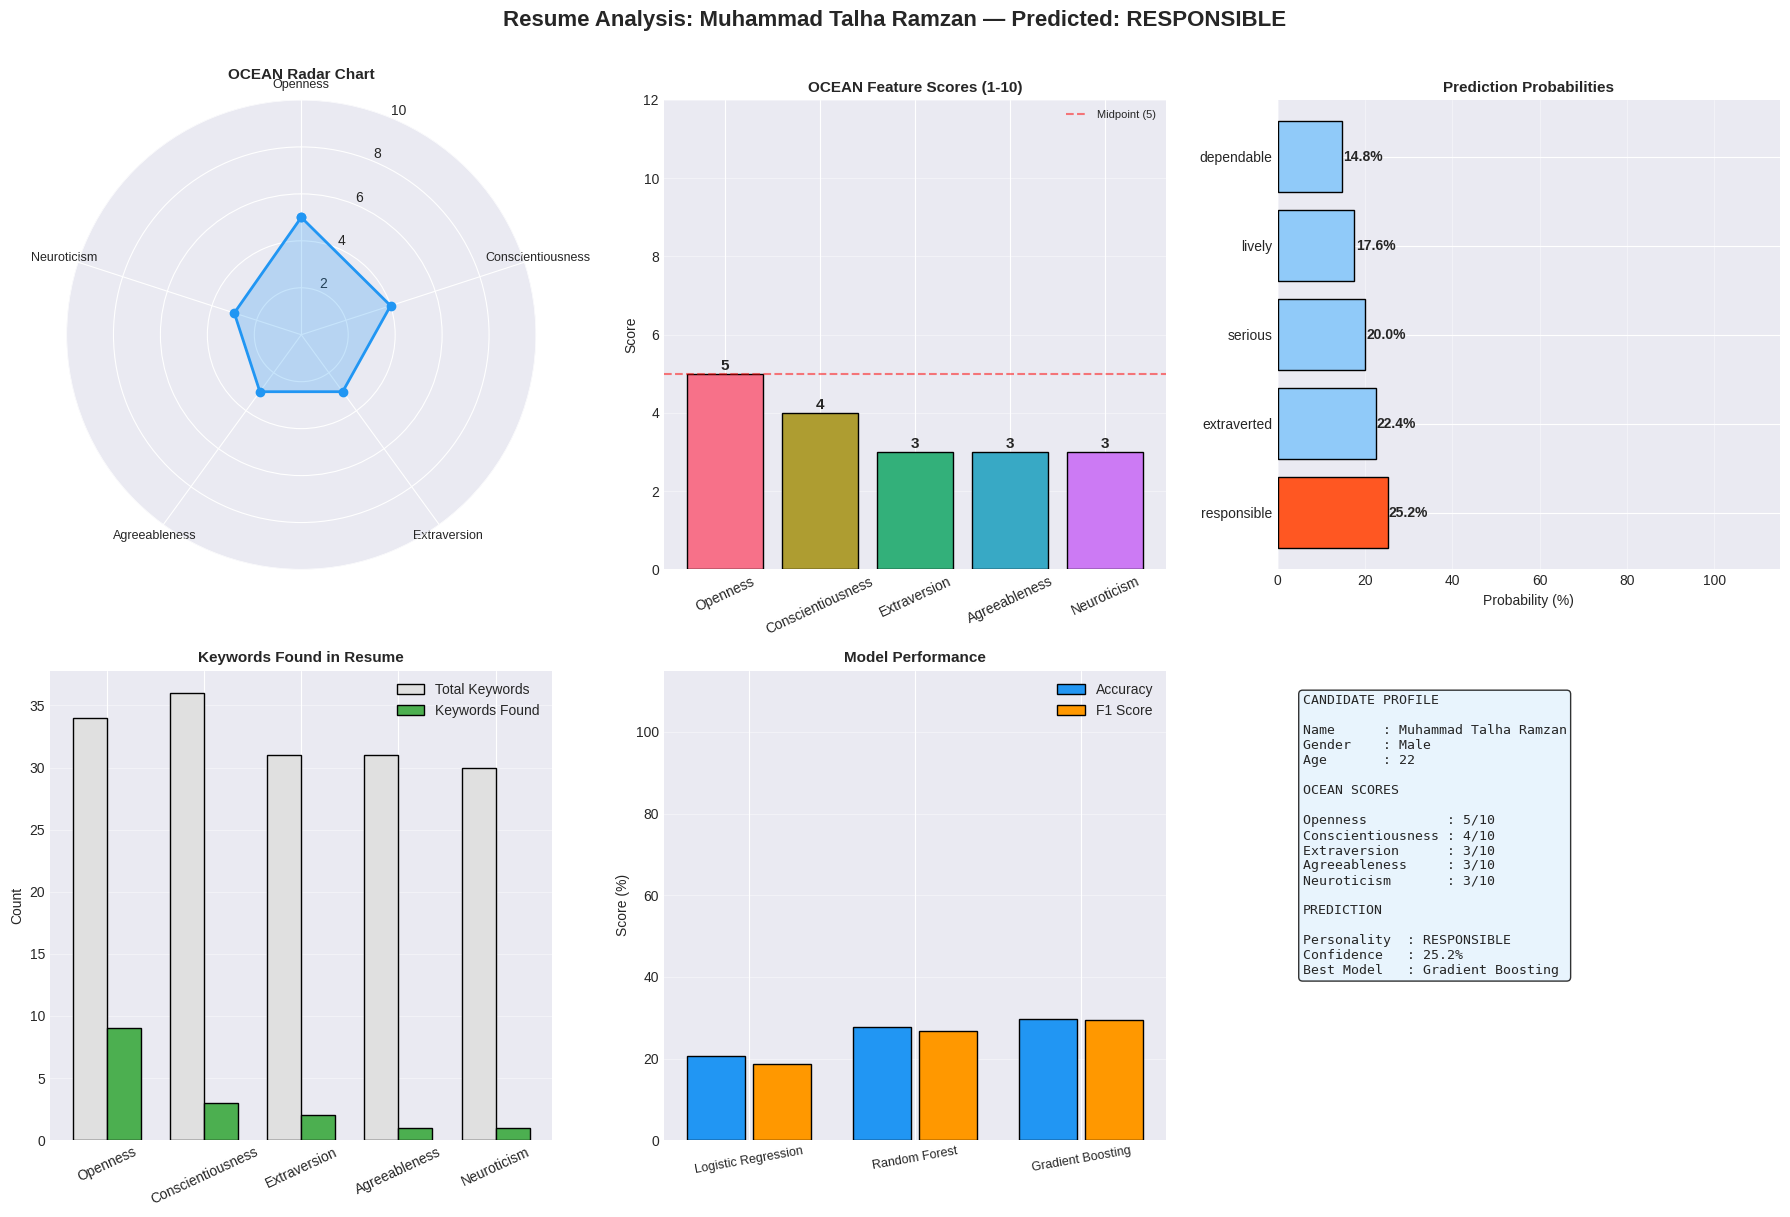

✅ Result Graph Saved: resume_analysis_result.png


In [10]:
# ================================================================
# CELL 8 — Upload Resume and Analyze
# ================================================================

print("="*55)
print("   📤 UPLOAD YOUR RESUME (PDF or DOCX)")
print("="*55)
print("\n⬇️ File chooser will open — select your resume\n")

# Upload file
uploaded = files.upload()

if uploaded:
    # Get uploaded file path
    resume_filename = list(uploaded.keys())[0]
    resume_path = f'/content/{resume_filename}'

    print(f"\n✅ File Uploaded: {resume_filename}")
    print(f"   File Size: {os.path.getsize(resume_path):,} bytes")

    # Analyze the resume
    result = analyze_resume(resume_path)

    if result:
        # Print results in console
        print("\n" + "="*55)
        print("   🎯 FINAL PREDICTION RESULT")
        print("="*55)
        print(f"\n   👤 Name        : {result['name']}")
        print(f"   ⚧ Gender      : {result['gender']}")
        print(f"   📅 Age         : {result['age']}")
        print(f"\n   📊 OCEAN Scores:")
        for trait, score in result['trait_scores'].items():
            bar = '█'*score + '░'*(10-score)
            print(f"      {trait.title():<20} [{bar}] {score}/10")
        print(f"\n   🎯 Predicted Personality : {result['prediction'].upper()}")
        print(f"   📊 Confidence            : {result['confidence']:.1f}%")
        print(f"   🏆 Model Used            : {best_name}")
        print(f"\n   📈 All Classes Probabilities:")
        for cls, pct in sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True):
            bar = '█' * int(pct/5)
            print(f"      {cls:<22} {bar:<20} {pct:.1f}%")

        # Plot graphs
        plot_resume_results(result)

else:
    print("⚠️ No file uploaded!")
    print("    Run the cell again and select a file.")